In [66]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

When a differentialequationgmodel consist of two or more differential equations, then its called a system of differential equations. 

$$y'=z-y\\
y'=h(z,y)\\
z'=z+y\\
z'=h(y,z)$$

When at least one of the differential equations in the system contains both functions or their derivatives, than they are coupled, and then we can't solve them independently of eachother. Its typically not possible to analytically find the expression for the ggeneral solution. So we will instead define a numerical solution.


we will solve the system using **Eulers method**  The idea is to determine for the solution f in relation to a differentialequation $y'=h(t,y)$ ,that satisfy the initial-value-problem $f(t_0)=y_0$. We want to determine the solution whose solution-curve passes through the point $P(t_0,y_0)$

$f'(t)=y'=h(t,y)\\$

The genereal solution curve at point P has a tangent with the equation 

$y=f'(t_0)(t-t_0)+f(t_0)\\
=h(t_0,y_0)(t-t_0)+y_0$

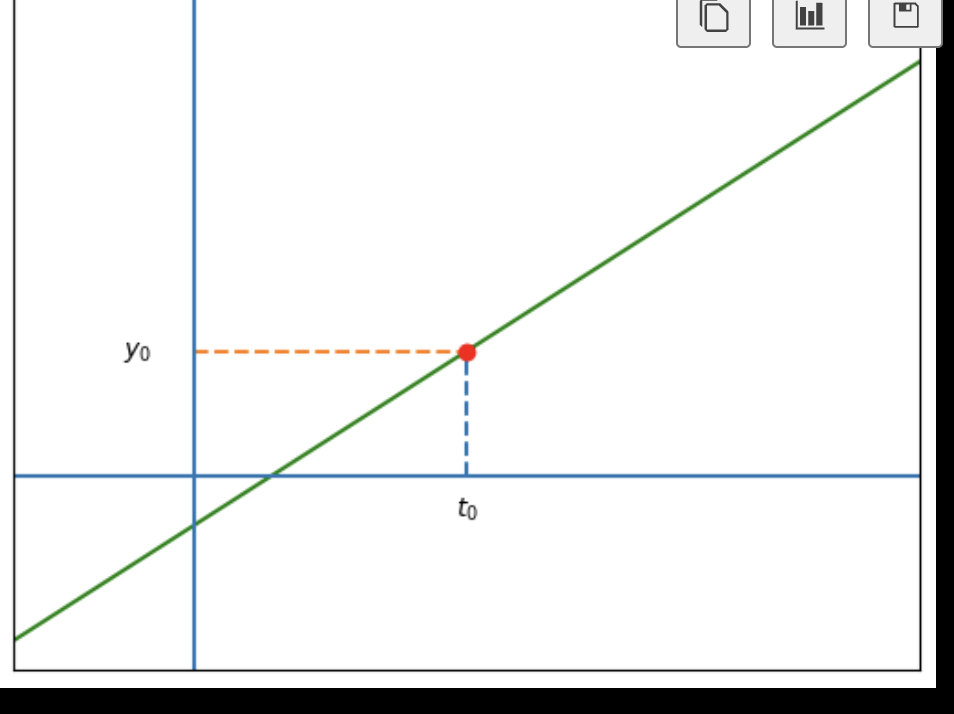 

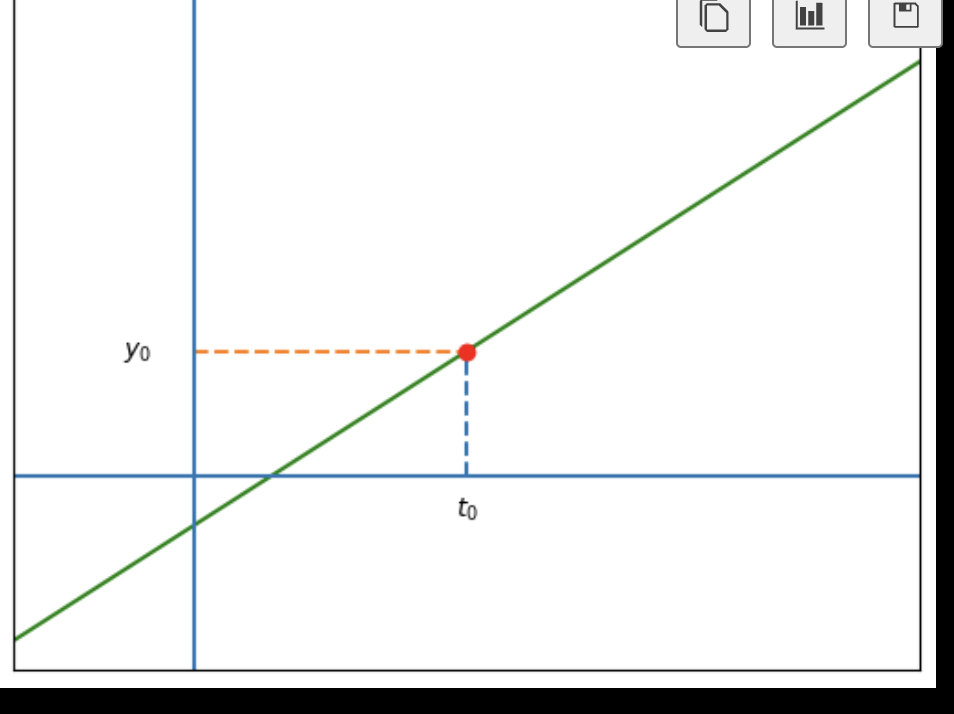



The idea behind Eulers is to use the tangent as an approximation aorund P. Follow the tangent a small step $\Delta T$-> stop-> adjust the slope-> follow the vectorslope field ->little step->adjust->..... repeat until the soluion over the interval we are interested in is found.

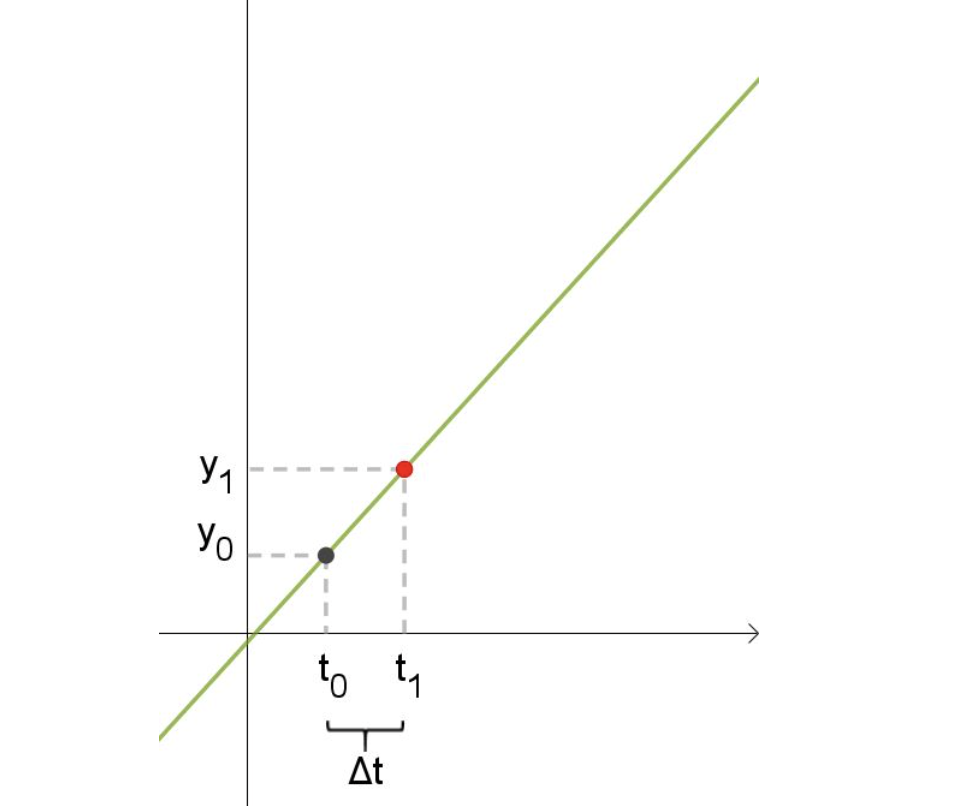
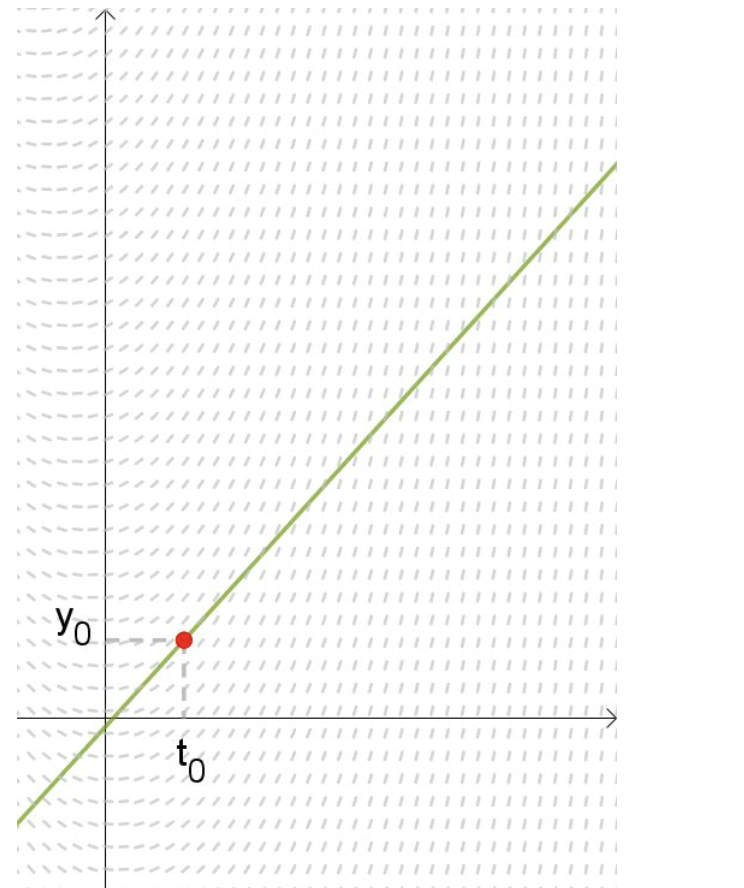

follow the tangent throug P with coordinates $(t_1,y_1)\\
t_1=t_0+\Delta T$. Determine $y_1$ by putting $t_1$ into the equation of the tangent:


$y=h(t_0,y_0)(t_1-t_0)+y_0\\
=h(t_0,y_0)(t_0+\Delta{t}-t_0)+y_0\\
=h(t_0,y_0)\Delta{t}+y_0$

$f(t_1) ≈y_1$ around the point P

We have to adjust the slope bye following the line element in the point $(t_1,y_1)$ The slope is then $h(t_1,y_1)$ 

the straight line through $(t_1,y_19)$ with the slope $h(t_1,y_1)$ :


$y=f'(t_1)(t-t_1)+f(t_1)\\
=h(t_1,y_1)(t-t_1)+y_1$

Do the same procedure with $y_2$ and so on
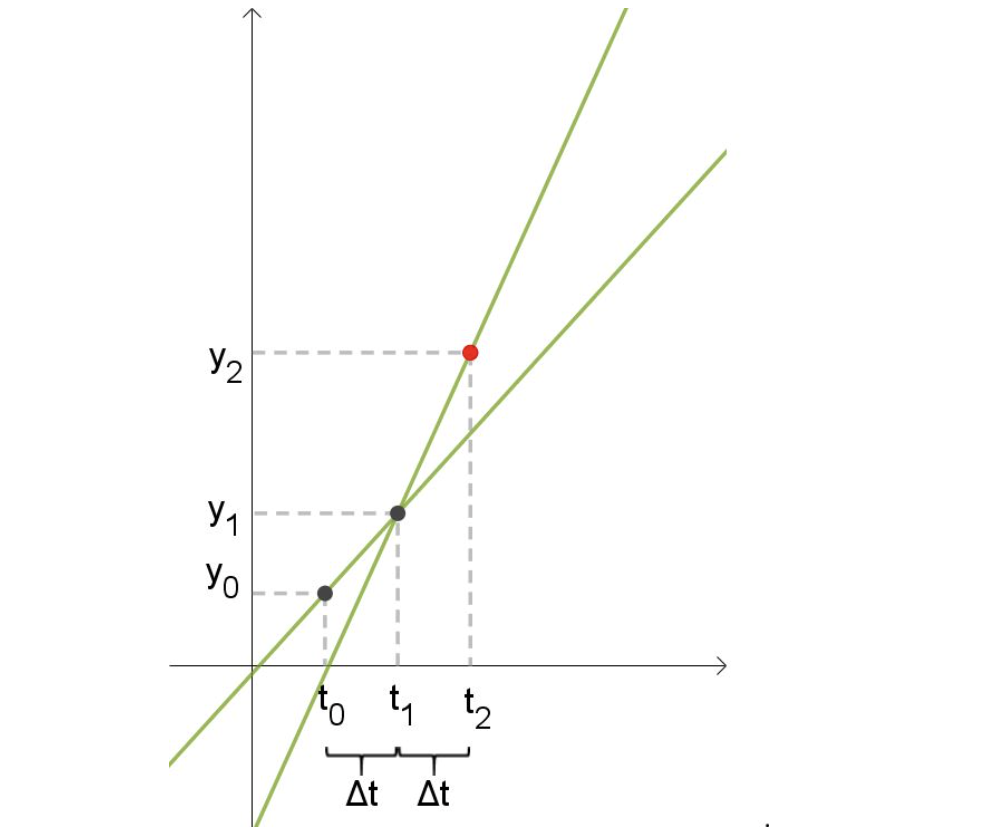
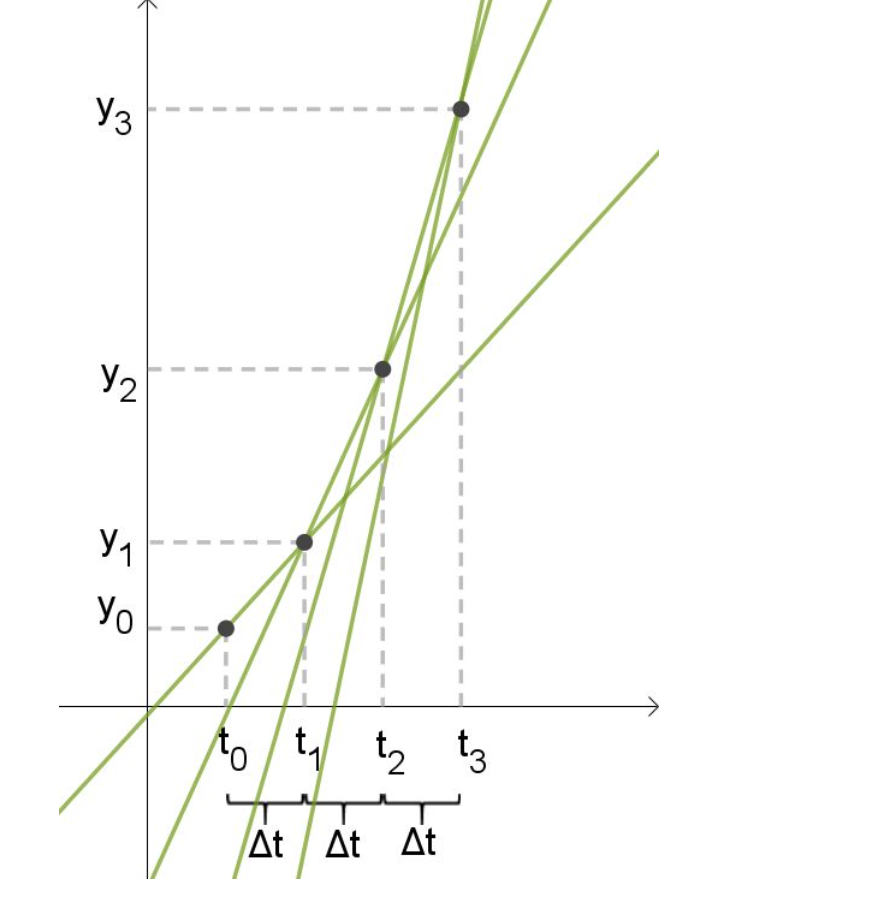


## How to use it
$t_{n+1}=t_n+\Delta{t}\\
y_{n+1}=h(t_n,y_n)\Delta{t}+y_n\\$

Lets make a code to solve first an ordinary differential equation and then a coupled differential equation system. We will use the one from the worshop document. Below youll find the solution to exercise 3.4


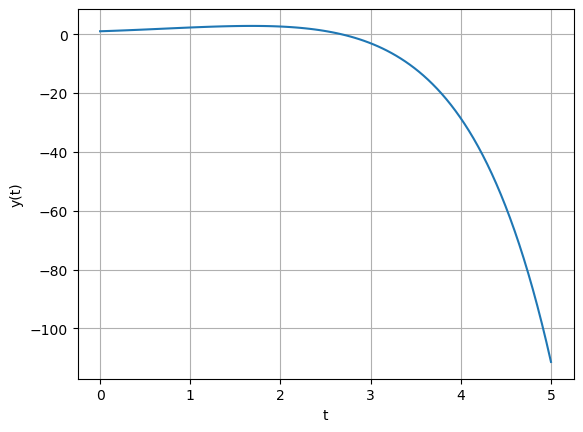

In [67]:
from scipy.integrate import solve_ivp
def f(t, y):
    dydt=y-t**2
    
    return dydt

#initial_conditions 
y0_random=[1]

#time_span
t_span=(0,5)

#time_steps
t_steps=100

#time_vector
t_random=np.linspace(t_span[0], t_span[1], t_steps)

#Solve equation

solution=solve_ivp(f, t_span, y0_random, t_eval=t_random)
plt.plot(solution.t, solution.y[0])
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid()
plt.show()

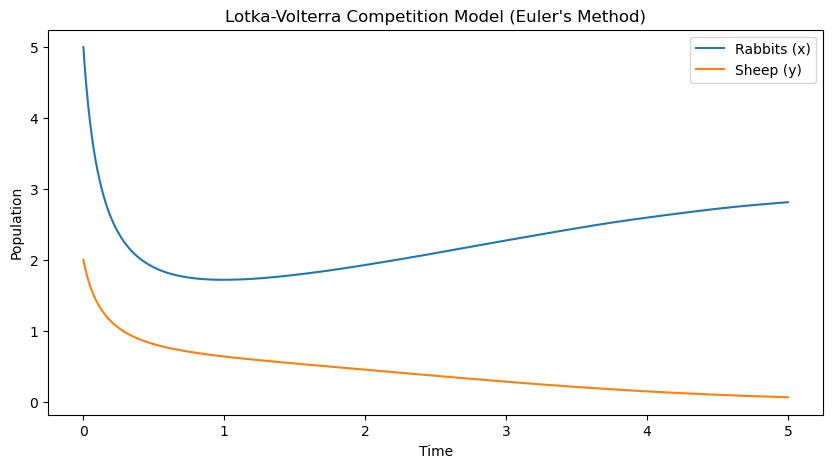

In [68]:
from scipy import integrate


def coupled_system(t, y):
    x, y = y
    dxdt = x * (3 - x - 2 * y)
    dydt = y * (2 - x - y)

    return np.array([dxdt, dydt])

initial_conditions = [5, 2] # Initial populations of rabbits and sheep randomly chosen

#Time intervals
t_span = (0, 5)  # from t=0 to t=5
t_eval = np.linspace(*t_span, 2000)  # 100 points in this interval

#Solve the differential equations using Euler's method
sol = integrate.solve_ivp(coupled_system, t_span, initial_conditions, t_eval=t_eval)


#Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(t_eval, sol.y[0], label='Rabbits (x)')
plt.plot(t_eval, sol.y[1], label='Sheep (y)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.title('Lotka-Volterra Competition Model (Euler\'s Method)')
plt.show()


### Problem 1)
is the system linear?

answer:
no- x*y and $x^2$ appear





## Problem 2)
Nullclines in phase space
$\dot x=0$
$x(3−x−2y)=0⇒x=0$
eller
$3−x−2y=0 ⇒x=3-2y$


$\dot y=0$
$y(2−x−y)=0⇒y=0$
eller
$2−x−y=0 ⇒x=2-y$

so the nullclines are the 4 lines:


$$x=0\\
y=0\\
x=3-2y\\
x=2-y$$






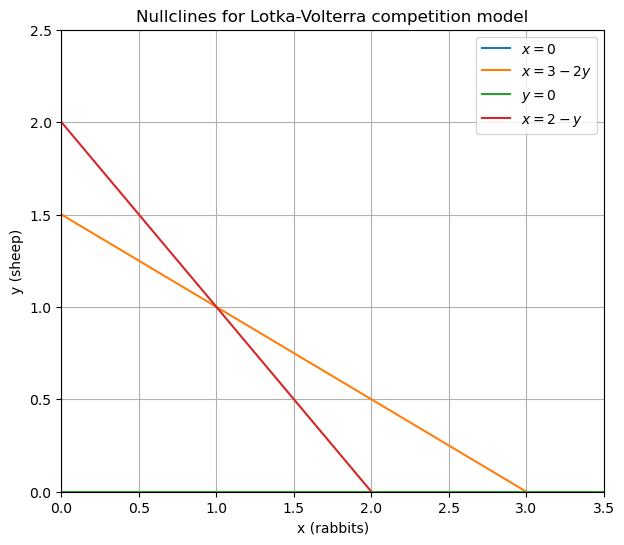

In [69]:
# y-akse variabel
y = np.linspace(0, 2.5, 400)

# x-akse variabel
x = np.linspace(0, 3.5, 400)

plt.figure(figsize=(7,6))

# dx/dt = 0
plt.plot(np.zeros_like(y), y, label=r"$x=0$")
plt.plot(3 - 2*y, y, label=r"$x=3-2y$")

# dy/dt = 0
plt.plot(x, np.zeros_like(x), label=r"$y=0$")
plt.plot(2 - y, y, label=r"$x=2-y$")

plt.xlim(0, 3.5)
plt.ylim(0, 2.5)

plt.xlabel("x (rabbits)")
plt.ylabel("y (sheep)")
plt.title("Nullclines for Lotka-Volterra competition model")
plt.legend()
plt.grid(True)
plt.show()

## Problem 3)
Find fixed points (where both ˙x and ˙y = 0 , i.e. crossings of nullclines).

The crossing gived 4 fixed points

1: x=0 and y=0 => (0,0)
2: x=0 and x=2-y =>y=2 => (0,2)
3: y=0 and x=3-2y =>x=3 (3,0)
4: x=3-2y and x=2-y:
3-2y=2-y => y=1, x=1 =>(1,1)

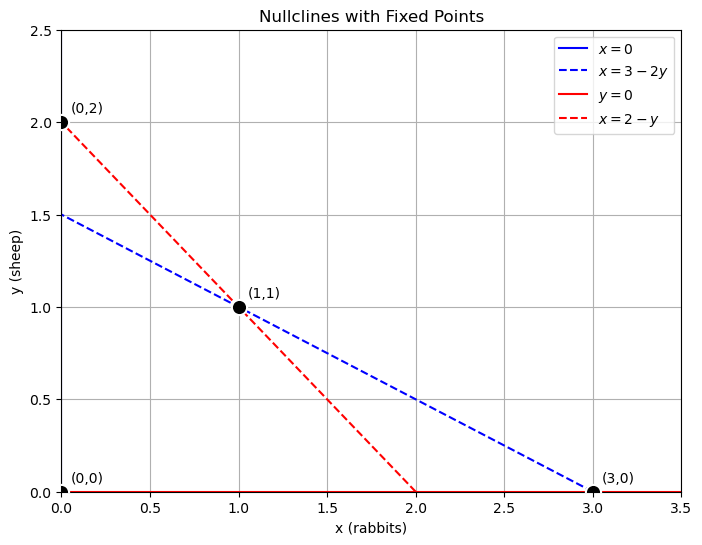

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Akser
y = np.linspace(0, 2.5, 400)
x = np.linspace(0, 3.5, 400)

plt.figure(figsize=(8,6))

# ---- Nullclines ----
plt.plot(np.zeros_like(y), y, 'b', label=r"$x=0$")
plt.plot(3 - 2*y, y, 'b--', label=r"$x=3-2y$")

plt.plot(x, np.zeros_like(x), 'r', label=r"$y=0$")
plt.plot(2 - y, y, 'r--', label=r"$x=2-y$")

# ---- Fixed Points ----
fixed_points = [(0,0), (3,0), (0,2), (1,1)]

for (xp, yp) in fixed_points:
    plt.scatter(xp, yp, 
                color='black', 
                s=120,          # større punkt
                edgecolors='white', 
                linewidth=1.5,
                zorder=5)       # sørger for de ligger øverst
    plt.text(xp+0.05, yp+0.05, f"({xp},{yp})")

plt.xlim(0, 3.5)
plt.ylim(0, 2.5)

plt.xlabel("x (rabbits)")
plt.ylabel("y (sheep)")
plt.title("Nullclines with Fixed Points")
plt.legend()
plt.grid(True)
plt.show()

## Problem 4)
 Find the stability of fixed points by putting the system into a vector equation 10 above and finding A. Then calculate the Jacobian of A.
Then insert the fixed point x and y values. 

Then calculate the eigenvalues of the Jacobian. If they are both positive, the fixed point is
unstable. If they are both negative, the point it stable. If one is positiv and one is negative, it is a "saddle-node" fixed point. Example take from p. 155 Strogatz 1994.

### Stability via jacobian and eigenvalues

$f(x,y)=x(3-x-2y)\\
g(x,y)=y(2-x-y)$

The **jacobian** is then:

$J(x,y)=\begin{bmatrix}
    \frac{∂f​}{∂x} & \frac{∂f​}{∂y} \\
    \frac{∂g​}{∂x}& \frac{∂g​}{∂y} \\
    \end{bmatrix}\\=\begin{bmatrix}
3-2x-2y & -2x \\
-y & 2-x-2y \\
\end{bmatrix}$

Evaluate by the fixpoints:

(0,0): 

$J=\begin{bmatrix}
3&0\\
0&2\\
 \end{bmatrix}$


$\begin{bmatrix}
{3-\lambda}&0\\
0&(2-{\lambda})\\
\end{bmatrix}=(3-\lambda)(2-\lambda)- 0=>\lambda =3,2$

 Both are posetive => unstable node(Source)


(3,0): 

$J=\begin{bmatrix}
-3&-6\\
0&-1\\
 \end{bmatrix}=> \lambda =-3,-1$

 Both are negative => stable node (sink)


(0,2): 

$J=\begin{bmatrix}
-1&0\\
-2&-2\\
 \end{bmatrix}=> \lambda =-1,-2$

 Both are negative => stable node (sink)

(1,1): 

$J=\begin{bmatrix}
-1&-2\\
-1&-1\\
 \end{bmatrix}=> $

trace=-2 and Det=(−1)(−1)−(−2)(−1)=1−2=−1<0 ⇒ one posetive, one negative => saddelpoint

 eigenvalues: $(-1-\lambda)(-1-\lambda)-(-2)(-1)=\lambda^2+1+2\lambda 2$
 $ => \lambda=-1+\sqrt 2$







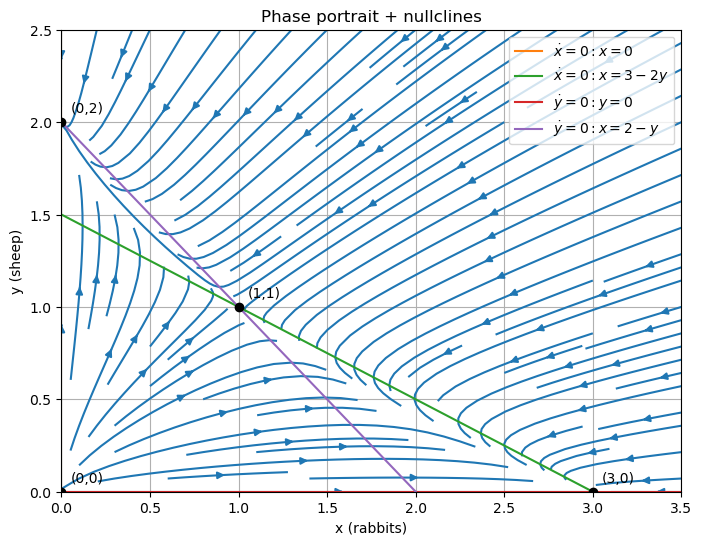

Fixed points and eigenvalues:
(0,0)  eigenvalues = [3. 2.]
(3,0)  eigenvalues = [-3. -1.]
(0,2)  eigenvalues = [-2. -1.]
(1,1)  eigenvalues = [ 0.41421356 -2.41421356]


In [71]:

# System of equations: We difened it as coupled system earlier


# Jacobian
def J(x, y):
    return np.array([
        [3 - 2*x - 2*y,  -2*x],
        [-y,             2 - x - 2*y]
    ], dtype=float)

# --- Plot nullclines + vector field ---
x = np.linspace(0, 3.5, 300)
y = np.linspace(0, 2.5, 300)
X, Y = np.meshgrid(x, y)
DX, DY = coupled_system(0, [X, Y])  # Compute the vector field at each point

plt.figure(figsize=(8, 6))

# Vector field (phase portrait)
plt.streamplot(X, Y, DX, DY, density=1.2)

# Nullclines
# dx=0: x=0 og x=3-2y
yy = np.linspace(0, 2.5, 300)
plt.plot(np.zeros_like(yy), yy, label=r"$\dot x=0: x=0$")
plt.plot(3 - 2*yy, yy, label=r"$\dot x=0: x=3-2y$")

# dy=0: y=0 og x=2-y
xx = np.linspace(0, 3.5, 300)
plt.plot(xx, np.zeros_like(xx), label=r"$\dot y=0: y=0$")
plt.plot(2 - yy, yy, label=r"$\dot y=0: x=2-y$")

# Fixed points
fixed_points = [(0,0), (3,0), (0,2), (1,1)]
for (xp, yp) in fixed_points:
    plt.plot(xp, yp, "ko")
    plt.text(xp+0.05, yp+0.05, f"({xp},{yp})")

plt.xlim(0, 3.5)
plt.ylim(0, 2.5)
plt.xlabel("x (rabbits)")
plt.ylabel("y (sheep)")
plt.title("Phase portrait + nullclines")
plt.grid(True)
plt.legend(loc="upper right")
plt.show()

# --- Eigenvalues by the fixed points ---
print("Fixed points and eigenvalues:")
for (xp, yp) in fixed_points:
    eigvals = np.linalg.eigvals(J(xp, yp))
    print(f"({xp},{yp})  eigenvalues = {eigvals}")